# Imports

In [14]:
import torch
from torch import nn
from torch.nn import CrossEntropyLoss
from segmentation_models_pytorch.losses import DiceLoss
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from LabelMapper import LabelMapper
from RuralDataset import RuralDataset
from SegmentationModel import SegmentationModel
from Trainer import Trainer
from Evaluator import Evaluator
from ImageProcessor import ImageProcessor
torch.cuda.empty_cache()

# Configuration parameters

In [15]:
DATA_ROOT = 'train'
BATCH_SIZE = 8
LEARNING_RATE = 0.0001
NUM_EPOCHS = 50
NUM_CLASSES = 9
MODEL_SAVE_PATH = 'saved_model.pth'

# Device configuration

In [16]:
if torch.cuda.is_available():
    device = torch.device('cuda')  # Configura per utilizzare la GPU
    print(f"Utilizzo GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')  # Fallback alla CPU
    print("CUDA non disponibile, utilizzo CPU")

Utilizzo GPU: NVIDIA GeForce RTX 5070 Ti


# Transforms initialization

In [17]:
train_transform = transforms.Compose([
    transforms.Resize((272,512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((272,512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Dataset loading and splitting into training and validation sets

In [18]:
# Crea dataset separati con le rispettive trasformazioni
from torch.utils.data import random_split

# Applica la trasformazione di training e validazione ai rispettivi dataset
full_dataset = RuralDataset(root_dir=DATA_ROOT)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Suddividi il dataset in train e val
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Applica le trasformazioni ai sotto-dataset
# NOTA: random_split restituisce Subset, quindi bisogna settare la transform manualmente
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, num_workers=16, shuffle=True,
    pin_memory=True)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, num_workers=16, shuffle=False,
    pin_memory=True)

print(f"Training on {len(train_dataset)} samples, validating on {len(val_dataset)} samples.")

Training on 695 samples, validating on 174 samples.


# Model initialization

In [19]:
model = SegmentationModel(NUM_CLASSES)
model.to(device)
print("Model architecture:")
print(model)

Model architecture:
SegmentationModel(
  (model): Unet(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=F

# Loss Function and optimizer definition

In [20]:
#weights =[ 3.8332,  1.0790,  0.7218,  0.7481,  0.8233,  0.3108,  1.7673, 70.4379, 12.8048]
weights = Trainer.compute_class_weights(train_loader, num_classes=NUM_CLASSES)
# Definizione della funzione di loss combinata
cross_entropy = CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32).to(device))
dice_loss = DiceLoss(mode='multiclass')
def combined_loss(pred, target):
    return cross_entropy(pred, target) + dice_loss(pred, target)
criterion = combined_loss

C:\Users\thatsrux\AppData\Local\Temp\ipykernel_20176\4274843505.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cross_entropy = CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32).to(device))


In [21]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Trainer initialization and training


Starting training...

Epoch 1/50
Batch 1/87, Loss: 3.6313
Batch 2/87, Loss: 3.3614
Batch 3/87, Loss: 3.1041
Batch 4/87, Loss: 3.0535
Batch 5/87, Loss: 3.3355
Batch 6/87, Loss: 3.0796
Batch 7/87, Loss: 2.9819
Batch 8/87, Loss: 3.0089
Batch 9/87, Loss: 3.1364
Batch 10/87, Loss: 3.6717
Batch 11/87, Loss: 2.7146
Batch 12/87, Loss: 2.7166
Batch 13/87, Loss: 2.8458
Batch 14/87, Loss: 2.6164
Batch 15/87, Loss: 2.8844
Batch 16/87, Loss: 2.8691
Batch 17/87, Loss: 2.8433
Batch 18/87, Loss: 2.7222
Batch 19/87, Loss: 2.6679
Batch 20/87, Loss: 2.5782
Batch 21/87, Loss: 2.7758
Batch 22/87, Loss: 2.9295
Batch 23/87, Loss: 2.8199
Batch 24/87, Loss: 2.9621
Batch 25/87, Loss: 2.7331
Batch 26/87, Loss: 2.7372
Batch 27/87, Loss: 2.7889
Batch 28/87, Loss: 2.4616
Batch 29/87, Loss: 2.7292
Batch 30/87, Loss: 2.6789
Batch 31/87, Loss: 2.6724
Batch 32/87, Loss: 2.6106
Batch 33/87, Loss: 3.0437
Batch 34/87, Loss: 2.5752
Batch 35/87, Loss: 2.6061
Batch 36/87, Loss: 2.4238
Batch 37/87, Loss: 2.5386
Batch 38/87, 

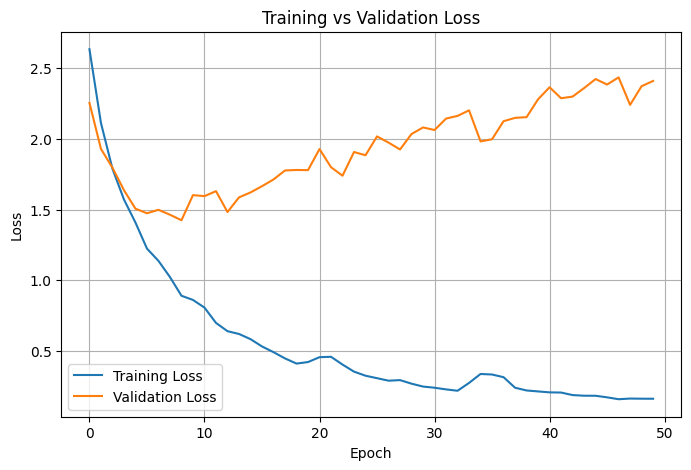

Training finished.


In [22]:
trainer = Trainer(model, train_loader, val_loader, criterion, optimizer, device)
print("\nStarting training...")
trainer.run(num_epochs=NUM_EPOCHS, model_save_path=MODEL_SAVE_PATH)
print("Training finished.")

# Model evaluation

In [23]:
model.load_state_dict(torch.load(MODEL_SAVE_PATH))

evaluator = Evaluator(model, val_loader, device)
metrics = evaluator.evaluate_classification_metrics()

# Example Predict

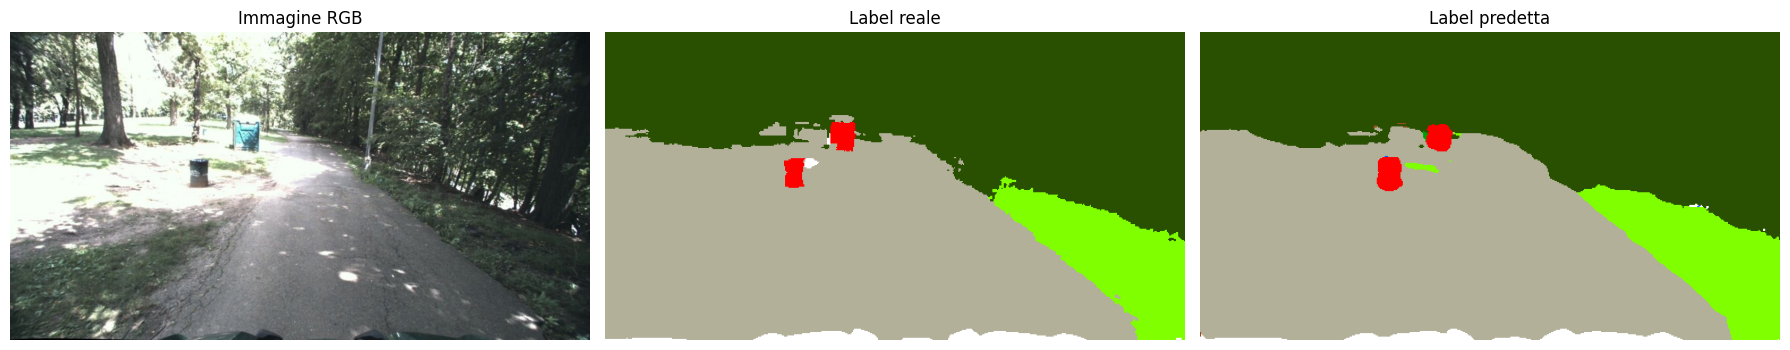

Pixel classificati correttamente: 137003 / 139264 (98.38%)
IoU medio sull'immagine: 0.5158
IoU per classe: [0.         0.         0.97352296 0.93925562 0.97706422 0.
        nan 0.72045855]


In [28]:
evaluator.predict_from_folder(folder_number = )

In [25]:
print(metrics.get('accuracy', 'N/A'))
print(metrics.get('f1_score', 'N/A'))
print(metrics.get('precision', 'N/A'))
print(metrics.get('recall', 'N/A'))

0.8134577030906651
N/A
0.6707787413394526
0.6458117250196236
